In [45]:
from __future__ import annotations

import operator
from typing import TypedDict,Annotated,List

from pydantic import BaseModel,Field
from langgraph.graph import StateGraph,START,END
from langgraph.types import Send

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage,SystemMessage

In [46]:
class Task(BaseModel):
    id:int
    title:str
    brief:str = Field(...,description="What to cover")

In [47]:
class Plan(BaseModel):
    blog_title:str
    tasks:List[Task]

In [48]:
class State(TypedDict):
    topic:str
    plan:Plan
    # reducer: results from workers get concatenated automatically
    sections:Annotated[List[str],operator.add]
    final:str


In [49]:
llm = ChatGroq(model='openai/gpt-oss-120b',api_key="REDACTED_GROQ_API_KEY")

In [50]:
#Orchestrator creates plan for blog
def orchestrator(state:State)->dict:
    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(content=("Create a blog plan with 5-7 sections on the following topic.")),
            HumanMessage(content=f"Topic:{state['topic']}")
        ]
    )

    return {'plan':plan}


In [51]:
# IMPORTANT:
# Send(node_name, state) does NOT call the function directly.
# It tells LangGraph:
# "Run this node with this state."
#
# Returning multiple Send objects = multiple parallel node executions
# (Fan-Out pattern).

def fanout(state: State):
    return [
        Send(
            "worker",
            {
                "task": task,
                "topic": state["topic"],
                "plan": state["plan"]
            }
        )
        for task in state["plan"].tasks
    ]

In [52]:
# Worker receives the payload (input state) sent by fanout().
# Payload contains the current task, blog topic, and full plan
# needed to generate one blog section.

def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}


In [53]:
from pathlib import Path

# Reducer (Fan-In):
# Collect all Markdown sections generated by parallel workers,
# combine them into a single blog, save it as a .md file,
# and return the final blog content to the graph state.

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)

    
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [54]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

g.add_edge(START,'orchestrator')
g.add_conditional_edges('orchestrator',fanout,['worker'])
g.add_edge('worker','reducer')
g.add_edge('reducer',END)

app = g.compile()

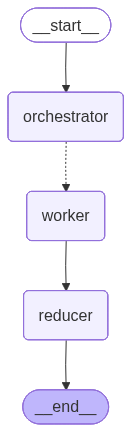

In [55]:
app

In [56]:
out = app.invoke({'topic':'PM Modi','sections':[]})

In [57]:
out['final']

'# The Leadership Journey of Prime Minister Narendra Modi: Vision, Policies, and Global Impact\n\n## Early Life and Political Rise\n\nNarendra Damodardas Modi was born on 17 September 1950 in Vadnagar, a small town in the northern part of Gujarat. Growing up in a modest family of a tea‑seller, Modi’s early years were shaped by the rhythms of a bustling market and the values of hard work and perseverance. He helped his father sell tea at the local railway station, an experience that later informed his grassroots connection with ordinary citizens.\n\n### Formative Influences\n\n- **Family and Community:** The modest household instilled in him a deep respect for self‑reliance and thrift. His mother’s devotion to religious and cultural practices also nurtured a strong sense of identity.\n- **Rashtriya Swayamsevak Sangh (RSS):** At the age of eight, Modi joined the RSS’s local shakha (branch). The organization’s emphasis on discipline, service, and nationalism left an indelible mark on his 